In [3]:
import os
HOME = os.getcwd()
print(HOME)

/kaggle/working


# import libraries

In [4]:
import numpy as np


In [5]:
%pip install ultralytics supervision roboflow
import ultralytics
ultralytics.checks()
!pip install "numpy<2.0"


Ultralytics 8.3.249 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
Setup complete ✅ (4 CPUs, 31.4 GB RAM, 6637.1/8062.4 GB disk)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.3/18.3 MB 80.8 MB/s eta 0:00:00:00:0100:01
  Attempting uninstall: numpy
    Found existing installation: numpy 2.2.6
    Uninstalling numpy-2.2.6:
      Successfully uninstalled numpy-2.2.6
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.12.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
datasets 4.4.1 requires pyarrow>=21.0.0, but you have pyarrow 19.0.1 which is incompatible.
cesium 0.12.4 requires numpy<3.0,>=2.0, but you have numpy 1.26.4 which is incompatible.
google-colab 1.0.0 requires notebook==6.5.7, but you have notebook 6.5.4 which is inc

# load datasets

In [6]:
from kaggle_secrets import UserSecretsClient
user_secrets = UserSecretsClient()
secret_value_0 = user_secrets.get_secret("api_key")

BackendError: Unexpected response from the service. Response: {'errors': ['No user secrets exist for kernel id 106488019 and label api_key.'], 'error': {'code': 5}, 'wasSuccessful': False}.

In [7]:
!mkdir {HOME}/datasets
%cd {HOME}/datasets
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="LYdQi8FZLABNnIXJ8OnO")
project = rf.workspace("baka-toast").project("oil-spill-two")
version = project.version(1)
dataset = version.download("yolov8")

/kaggle/working/datasets
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to oil-spill-two-1 in yolov8:: 100%|██████████| 19234/19234 [00:02<00:00, 7937.90it/s] 


In [10]:
os.environ['WANDB_MODE'] = 'disabled'

In [11]:
!ls /kaggle/working/datasets/oil-spill-two-1


data.yaml  README.dataset.txt  README.roboflow.txt  test  train  valid


In [12]:
%%writefile /kaggle/working/datasets/oil-spill-two-1/data.yaml
path: /kaggle/working/datasets/oil-spill-two-1

train: train/images
val: valid/images
test: test/images

nc: 1
names: ['oil_spill']


Overwriting /kaggle/working/datasets/oil-spill-two-1/data.yaml


# train

In [13]:
!yolo task=detect \
mode=train \
model=yolov8s.pt \
data=/kaggle/working/datasets/oil-spill-two-1/data.yaml \
epochs=25 \
imgsz=640 \
batch=16 \
name=oil_spill_yolov8s2 \
plots=True


Ultralytics 8.3.249 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/datasets/oil-spill-two-1/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=25, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=oil_spill_yolov8s2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, 

# plot train results

(-0.5, 2399.5, 1199.5, -0.5)

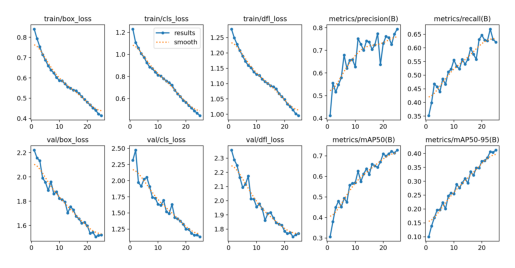

In [14]:
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open('/kaggle/working/datasets/runs/detect/oil_spill_yolov8s2/results.png')
plt.imshow(img)
plt.axis('off')


(-0.5, 2999.5, 2249.5, -0.5)

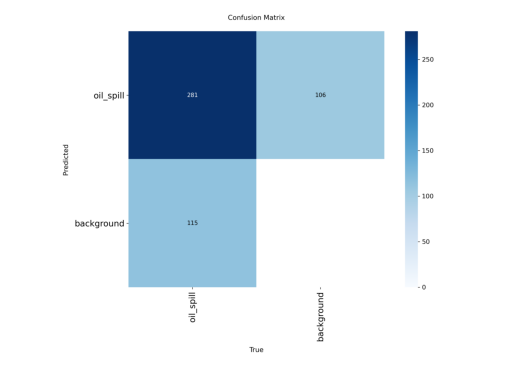

In [15]:
img = Image.open('/kaggle/working/datasets/runs/detect/oil_spill_yolov8s2/confusion_matrix.png')
plt.imshow(img)
plt.axis('off')


In [16]:
from pathlib import Path


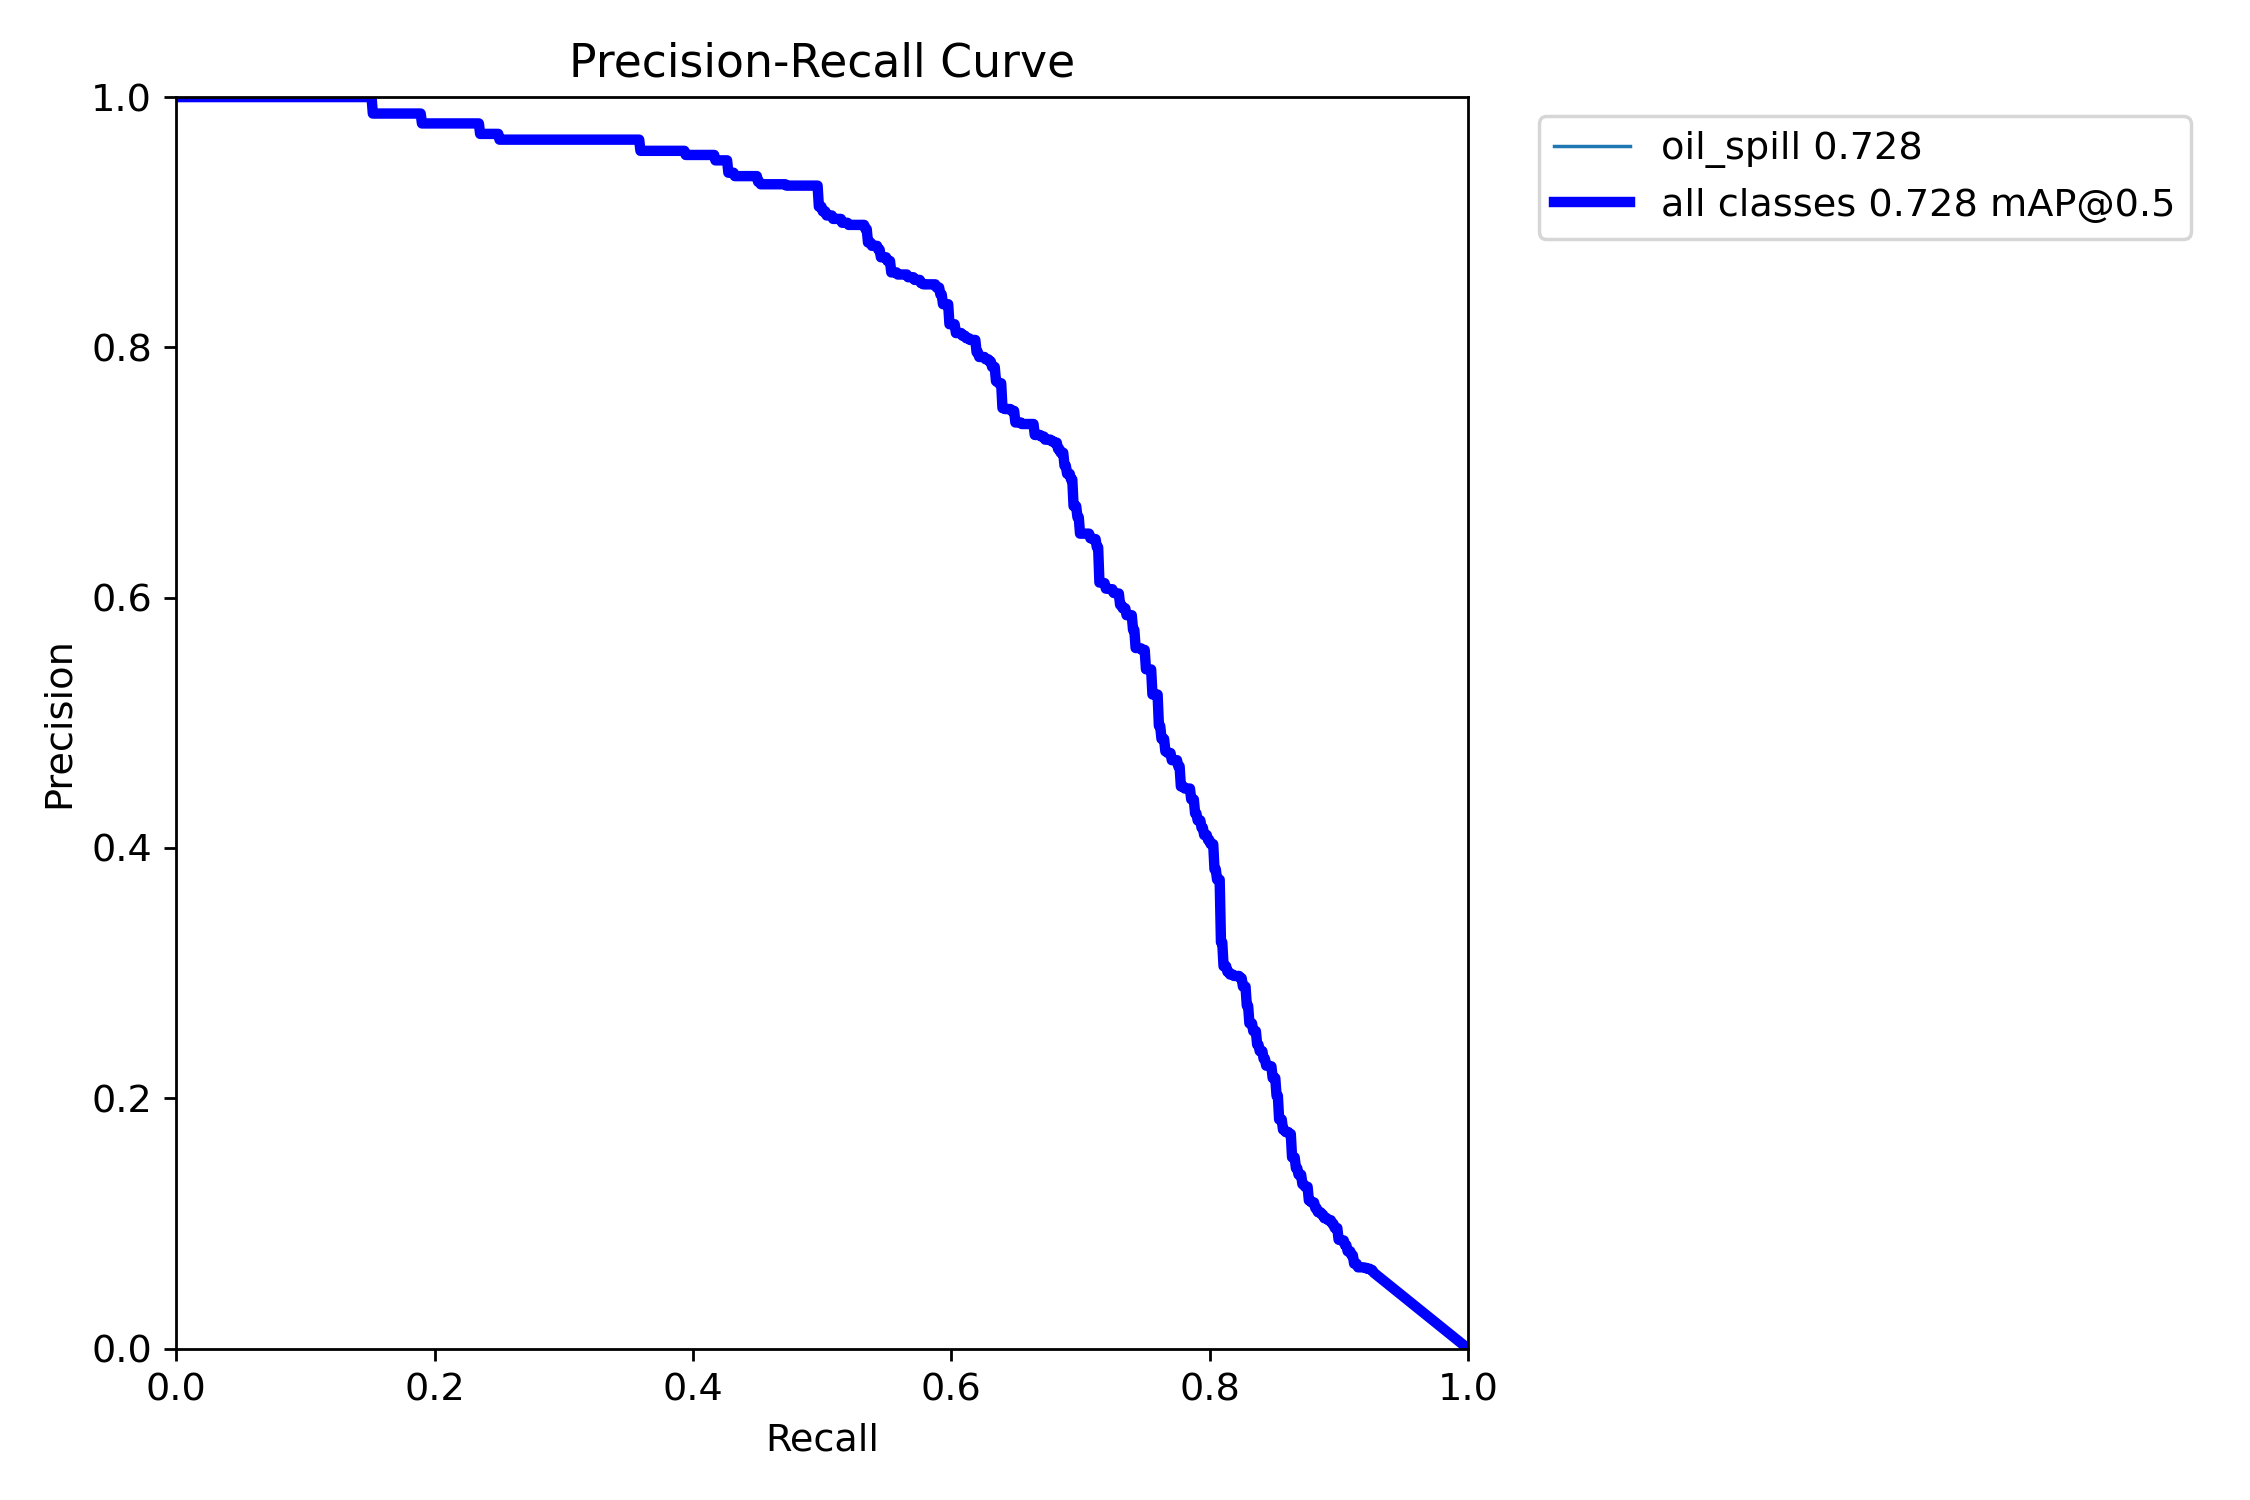

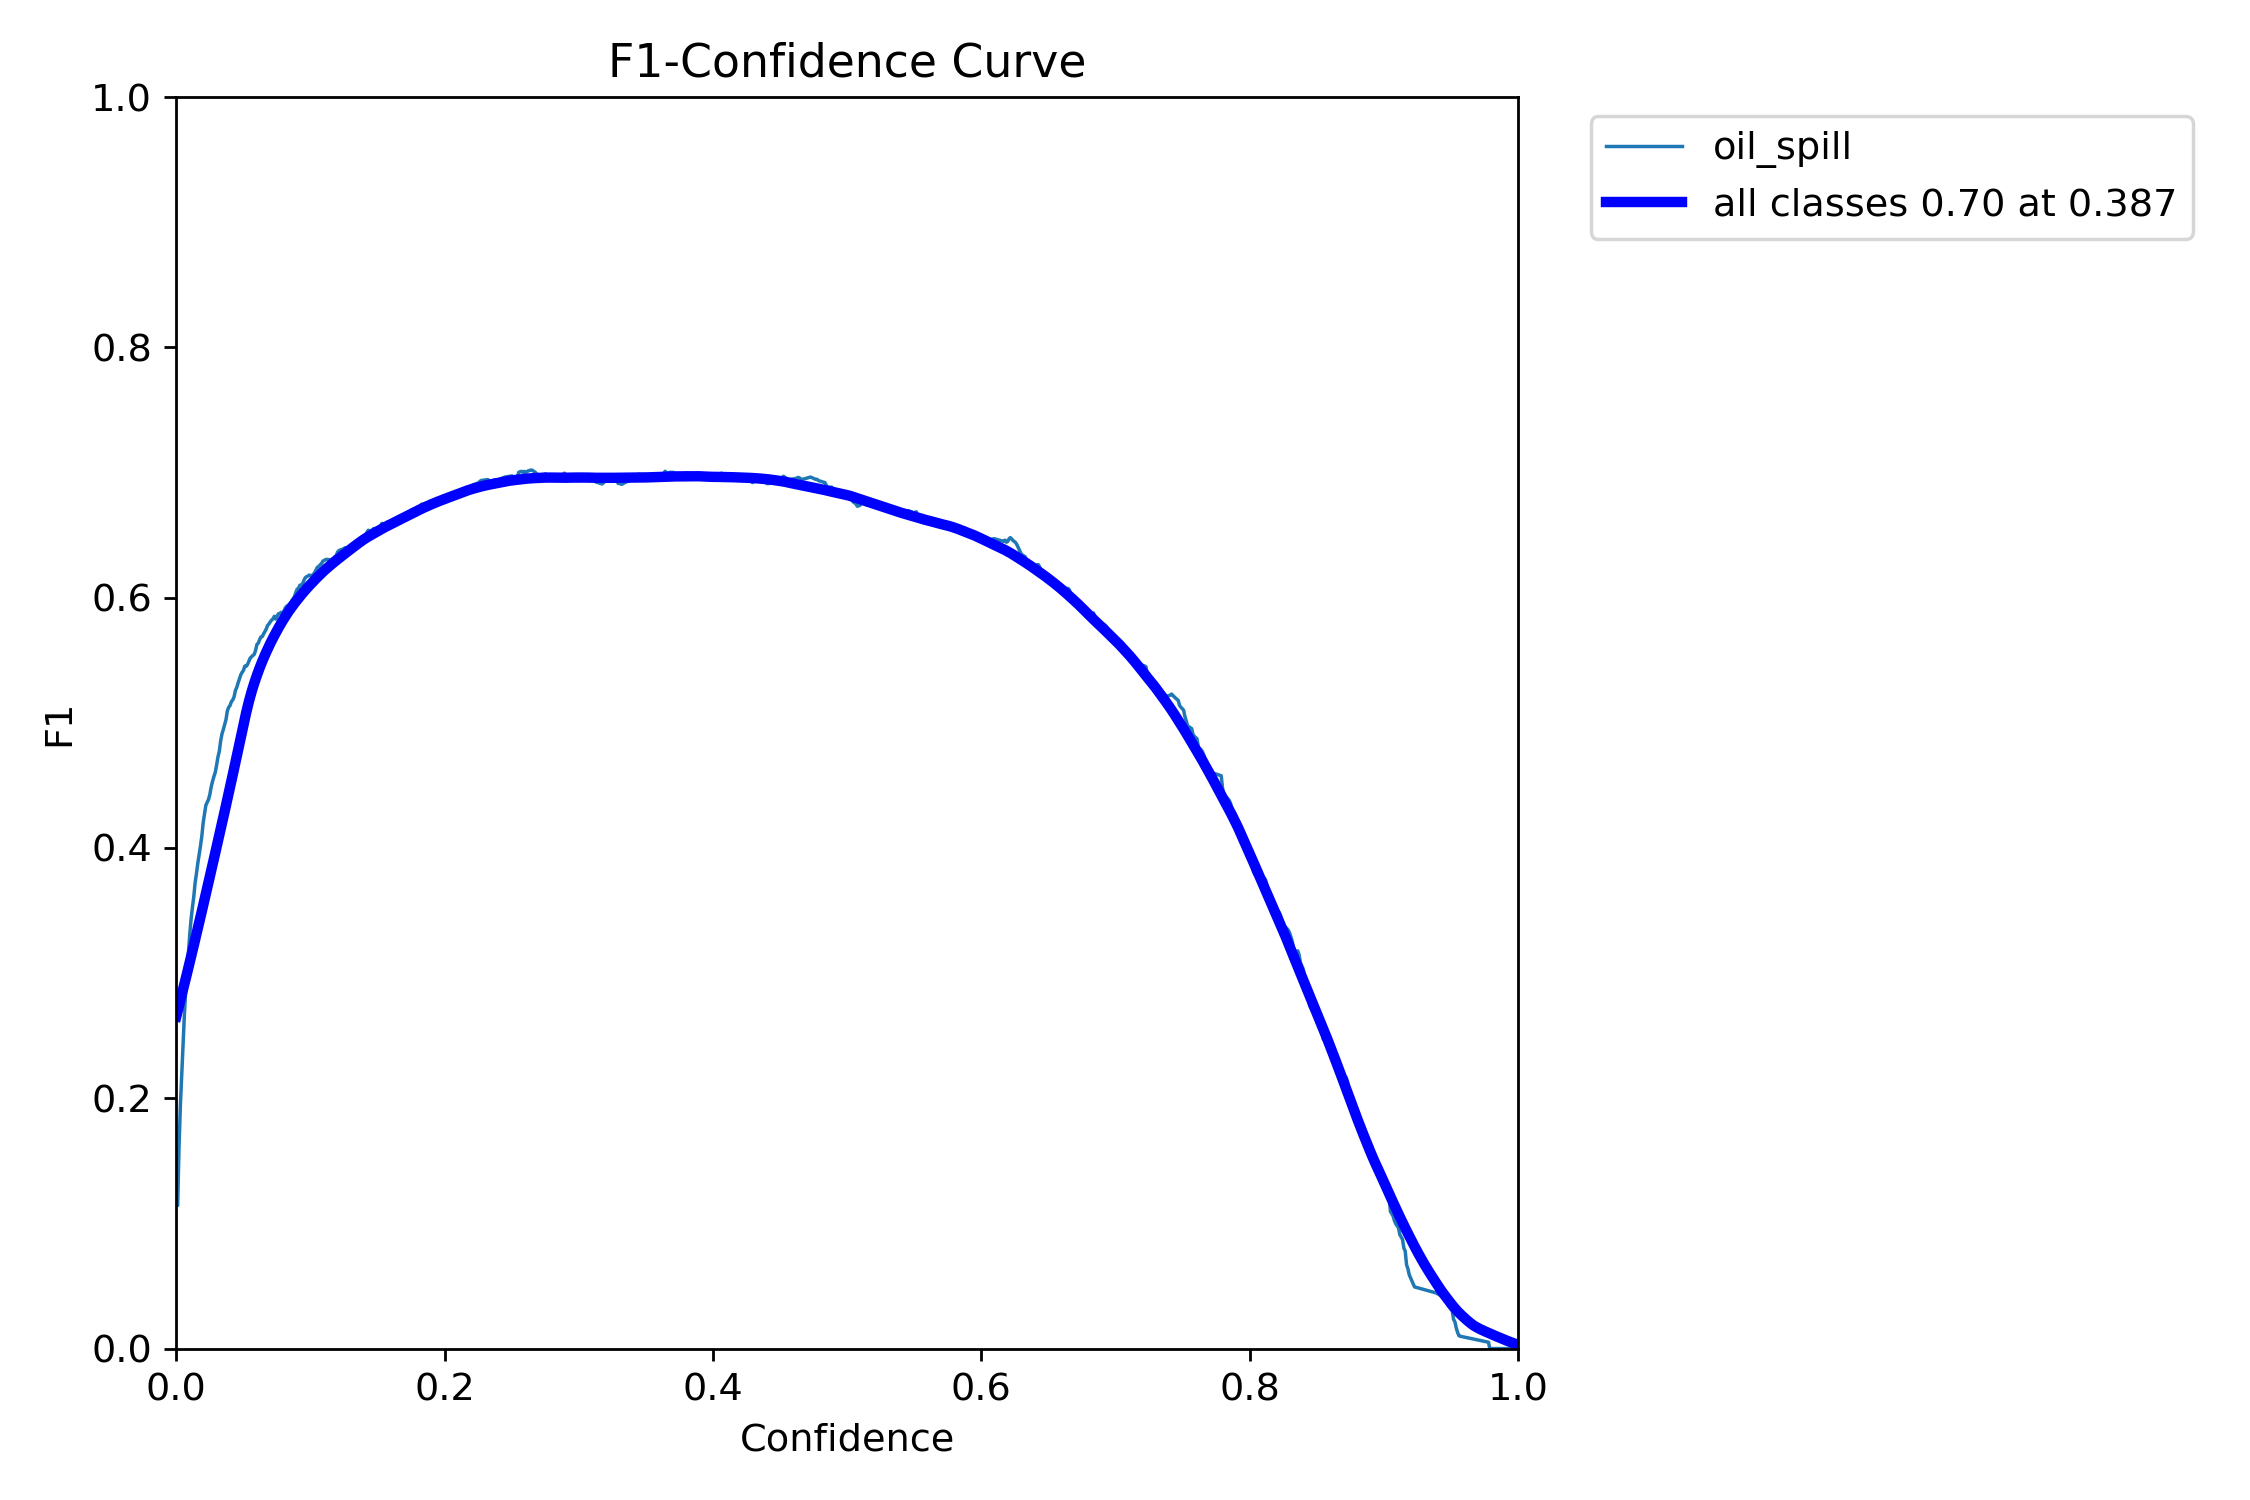

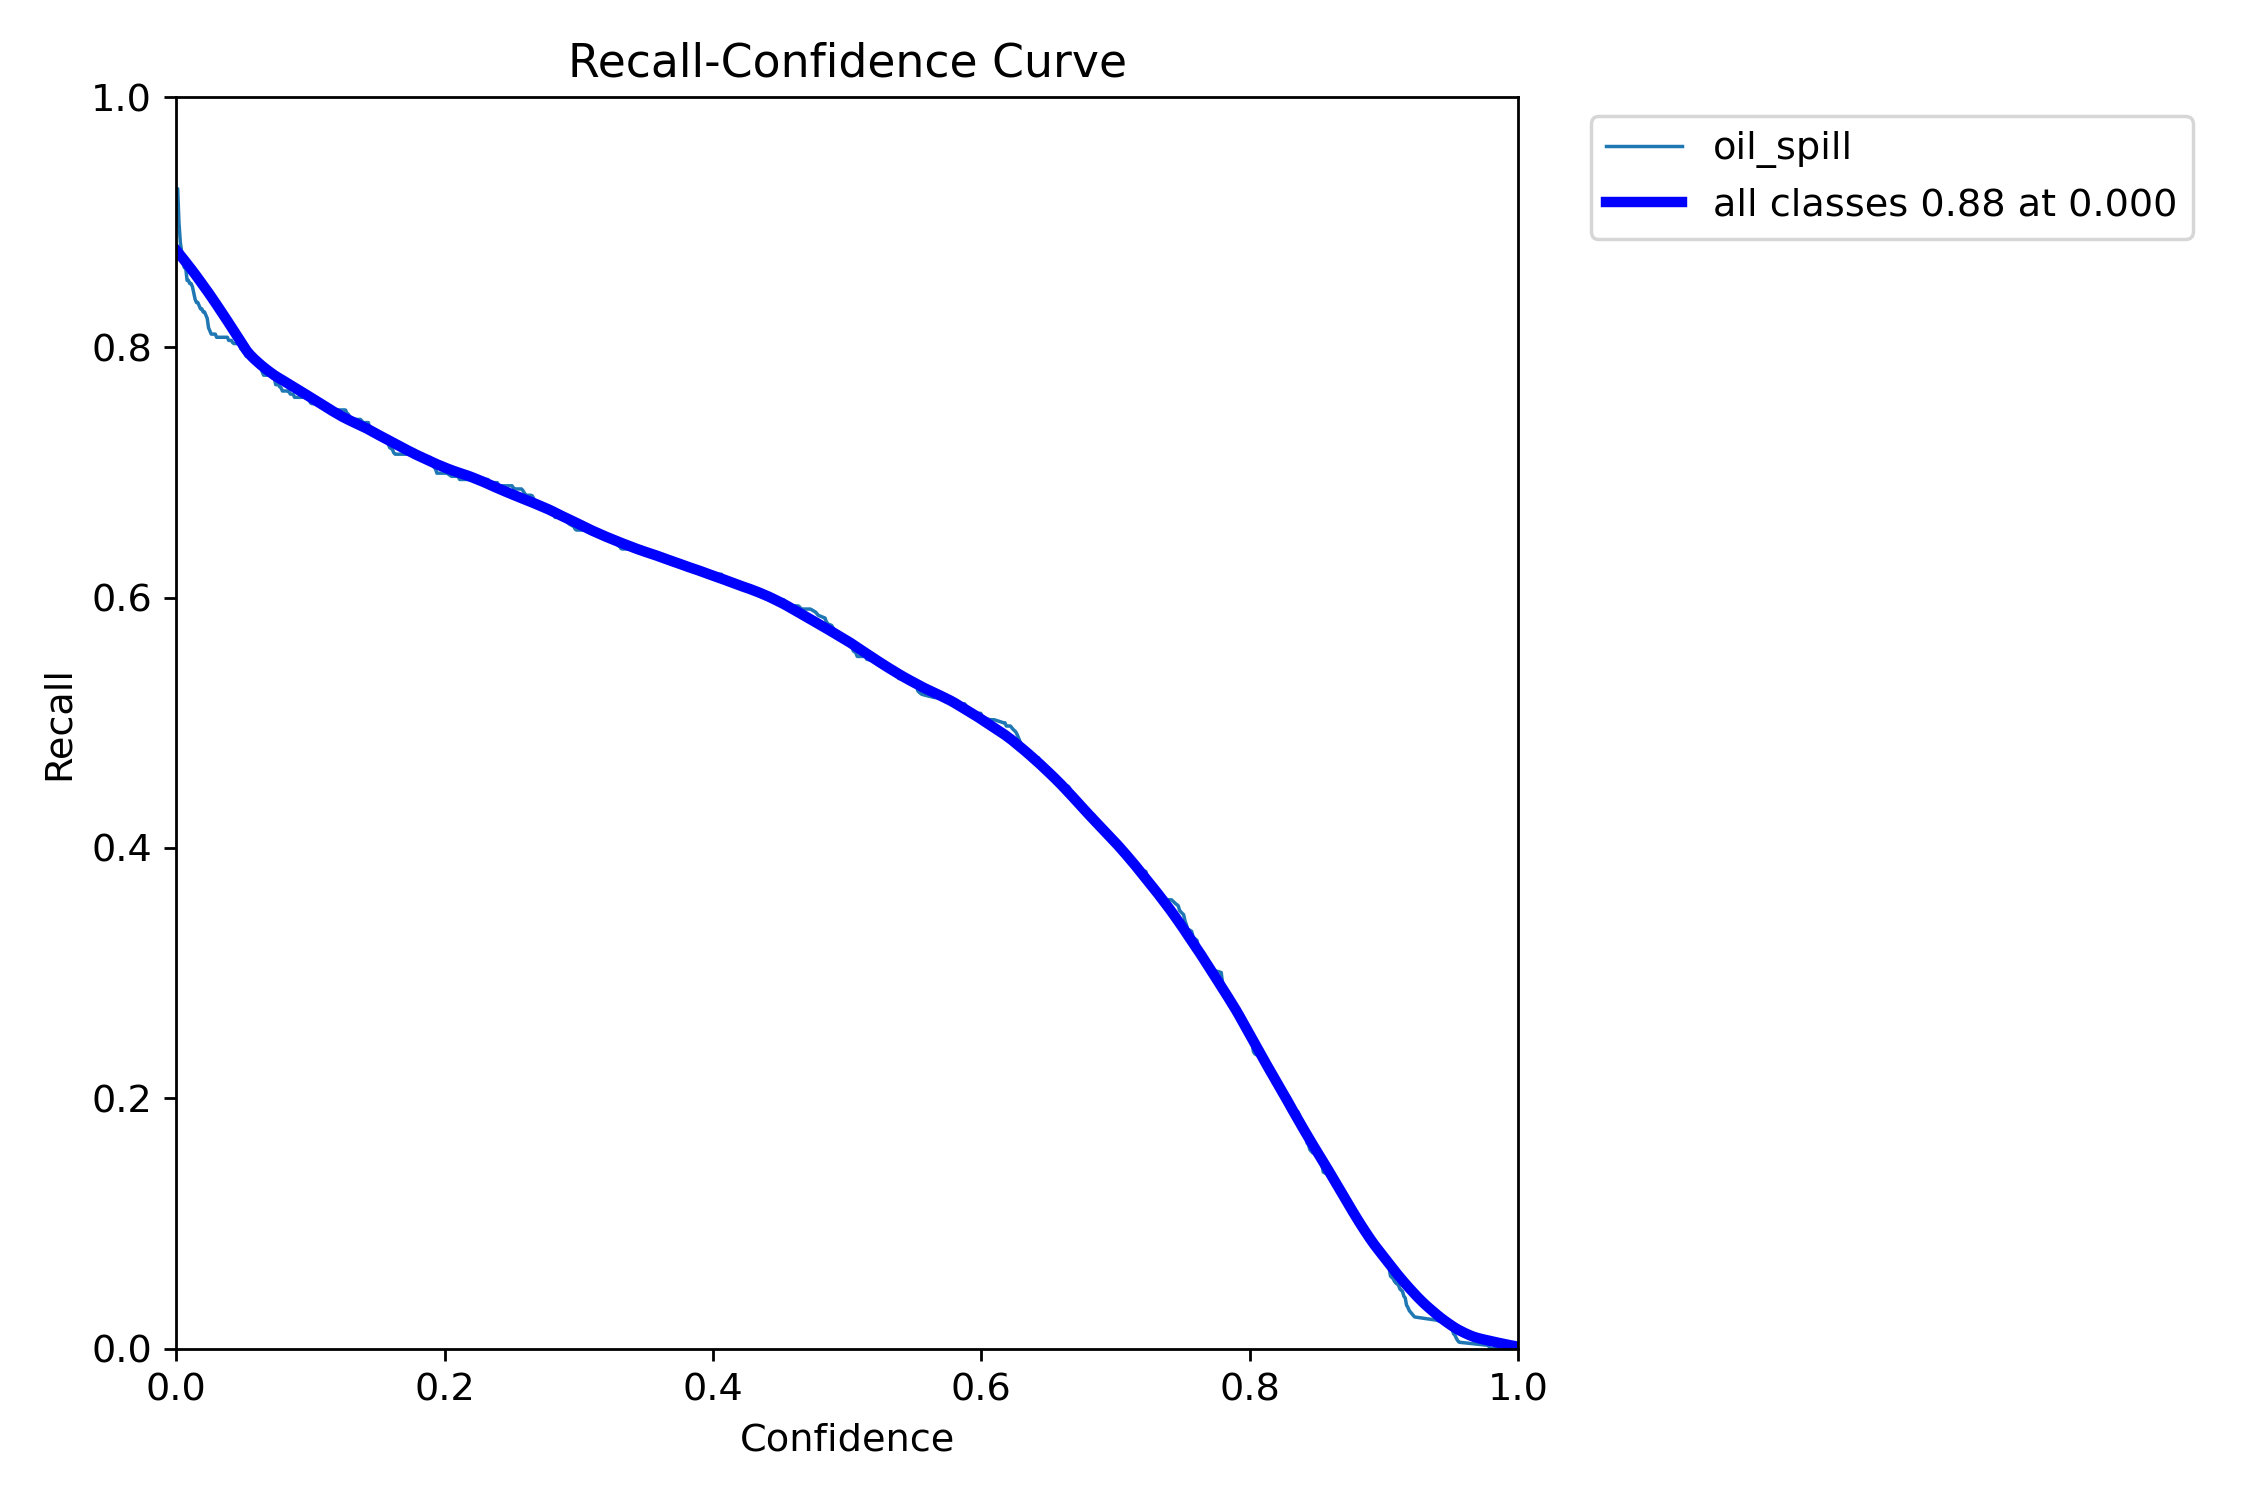

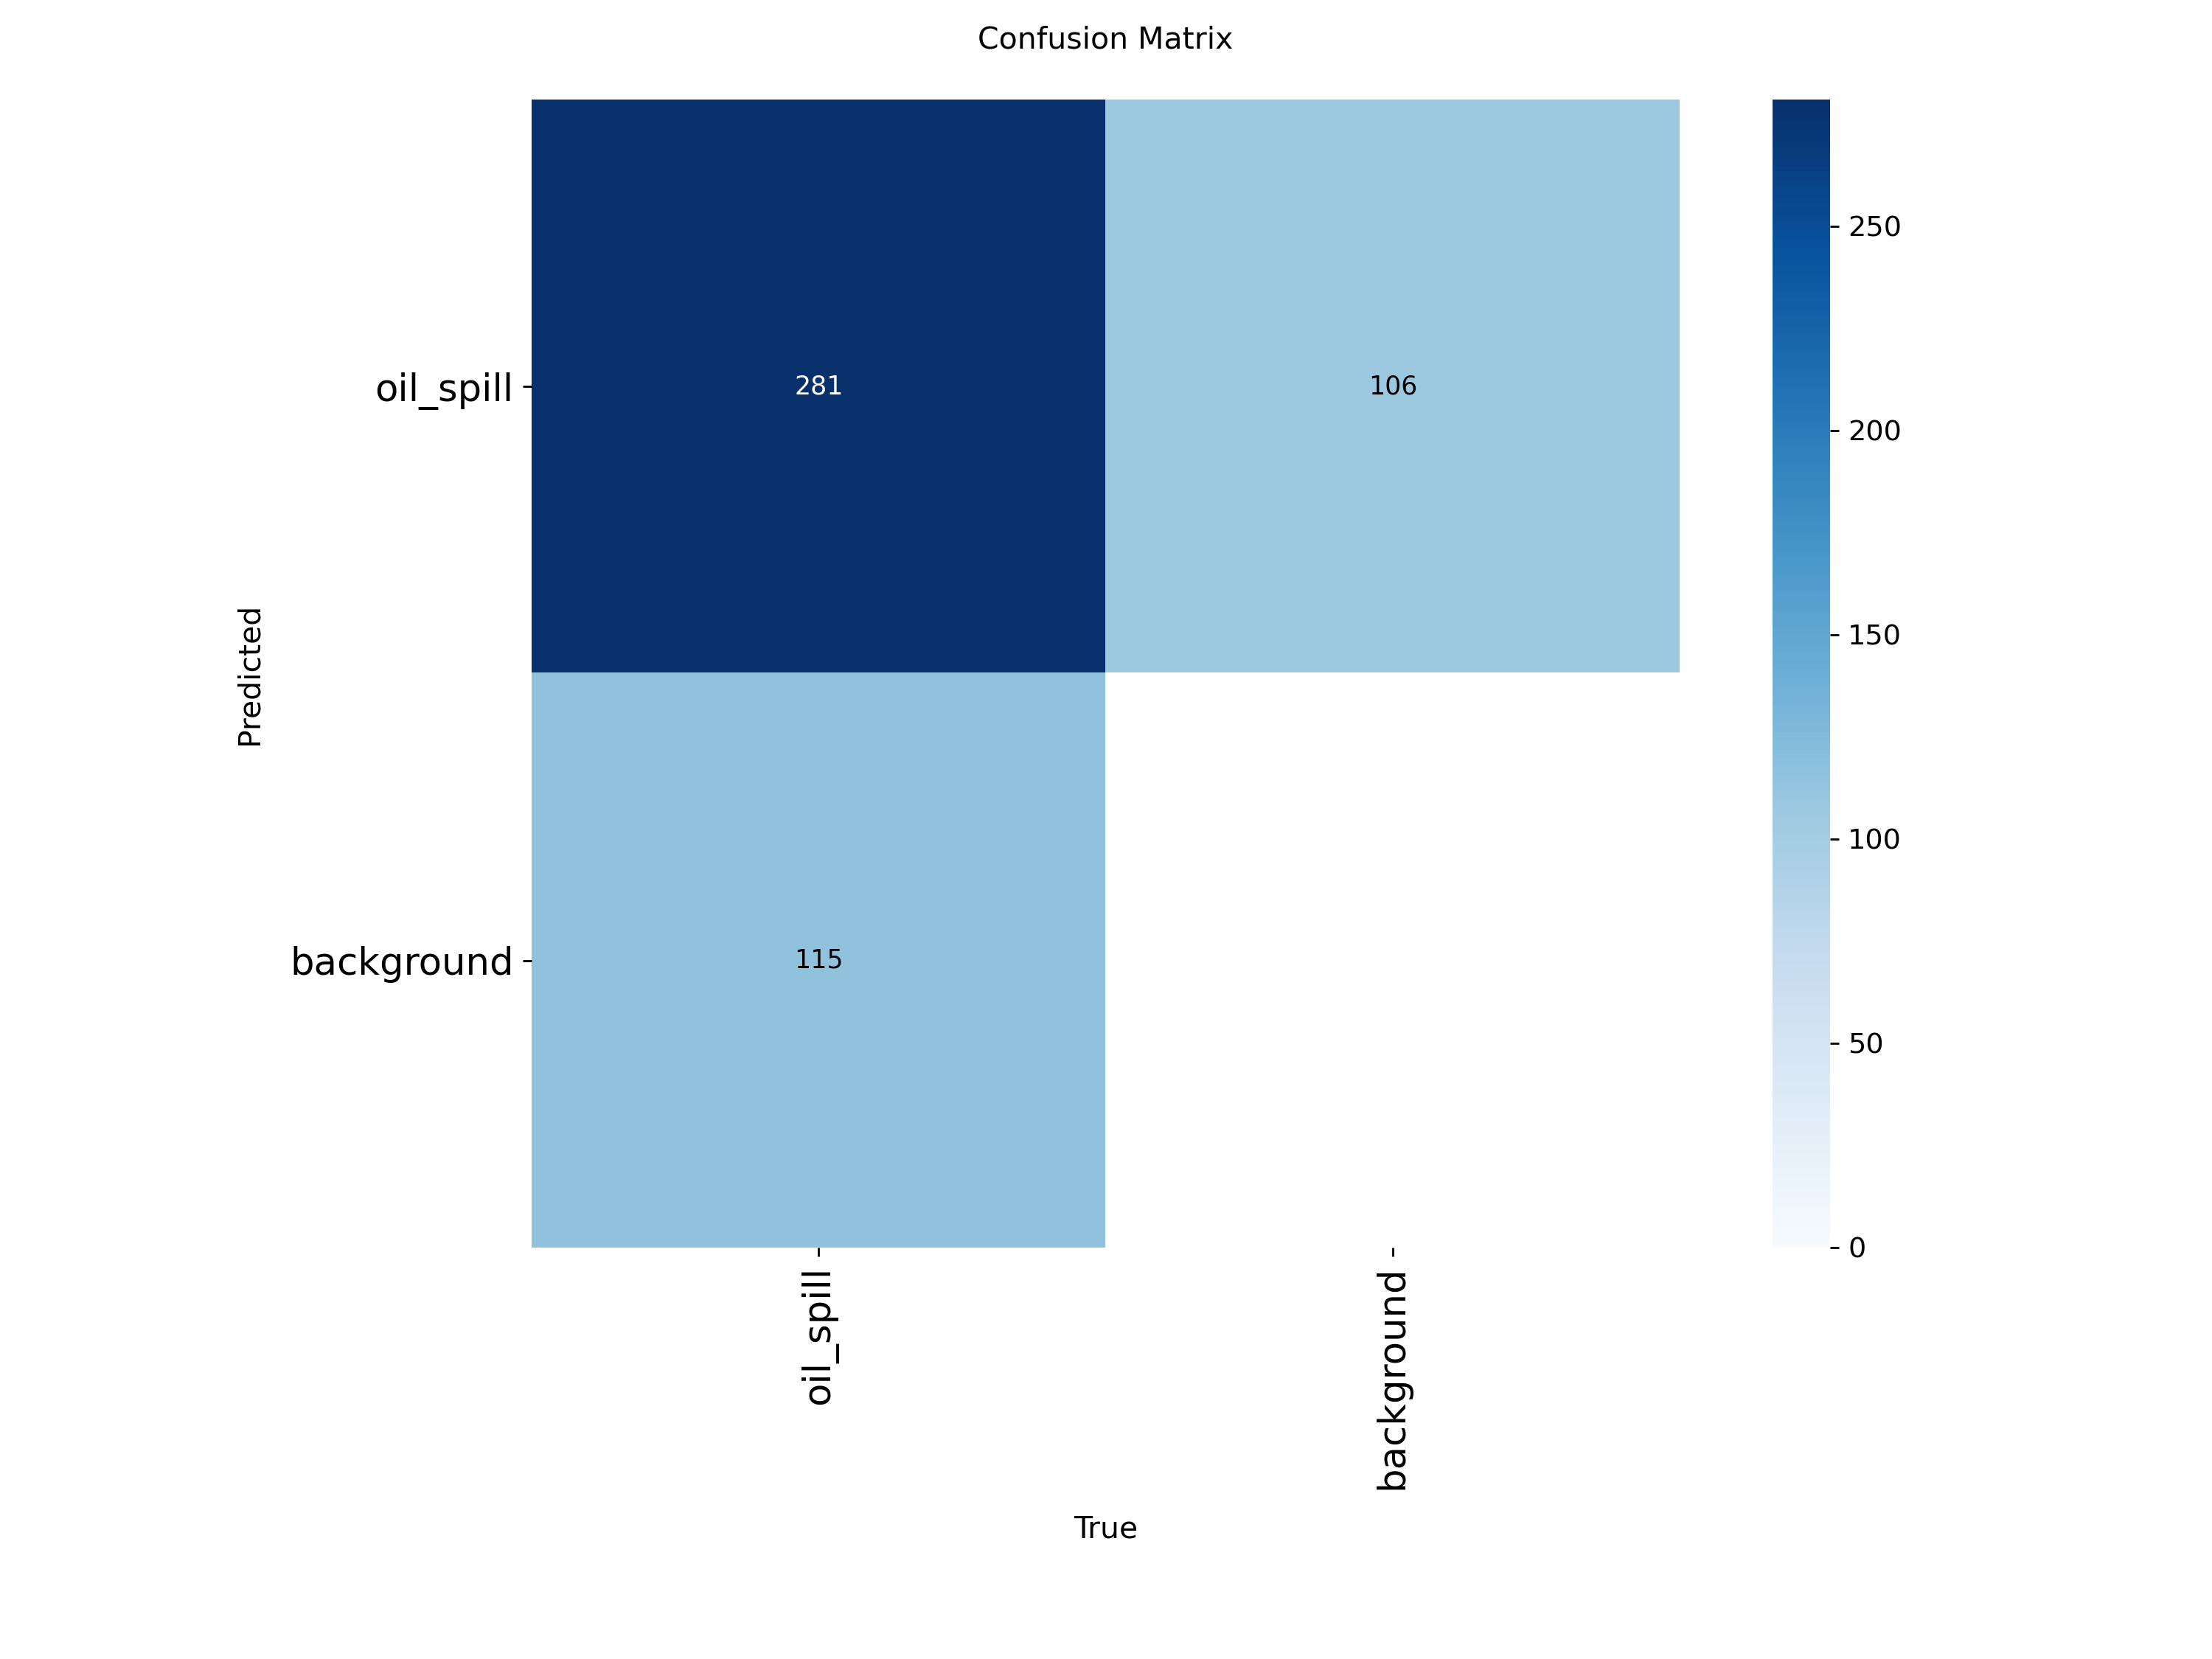

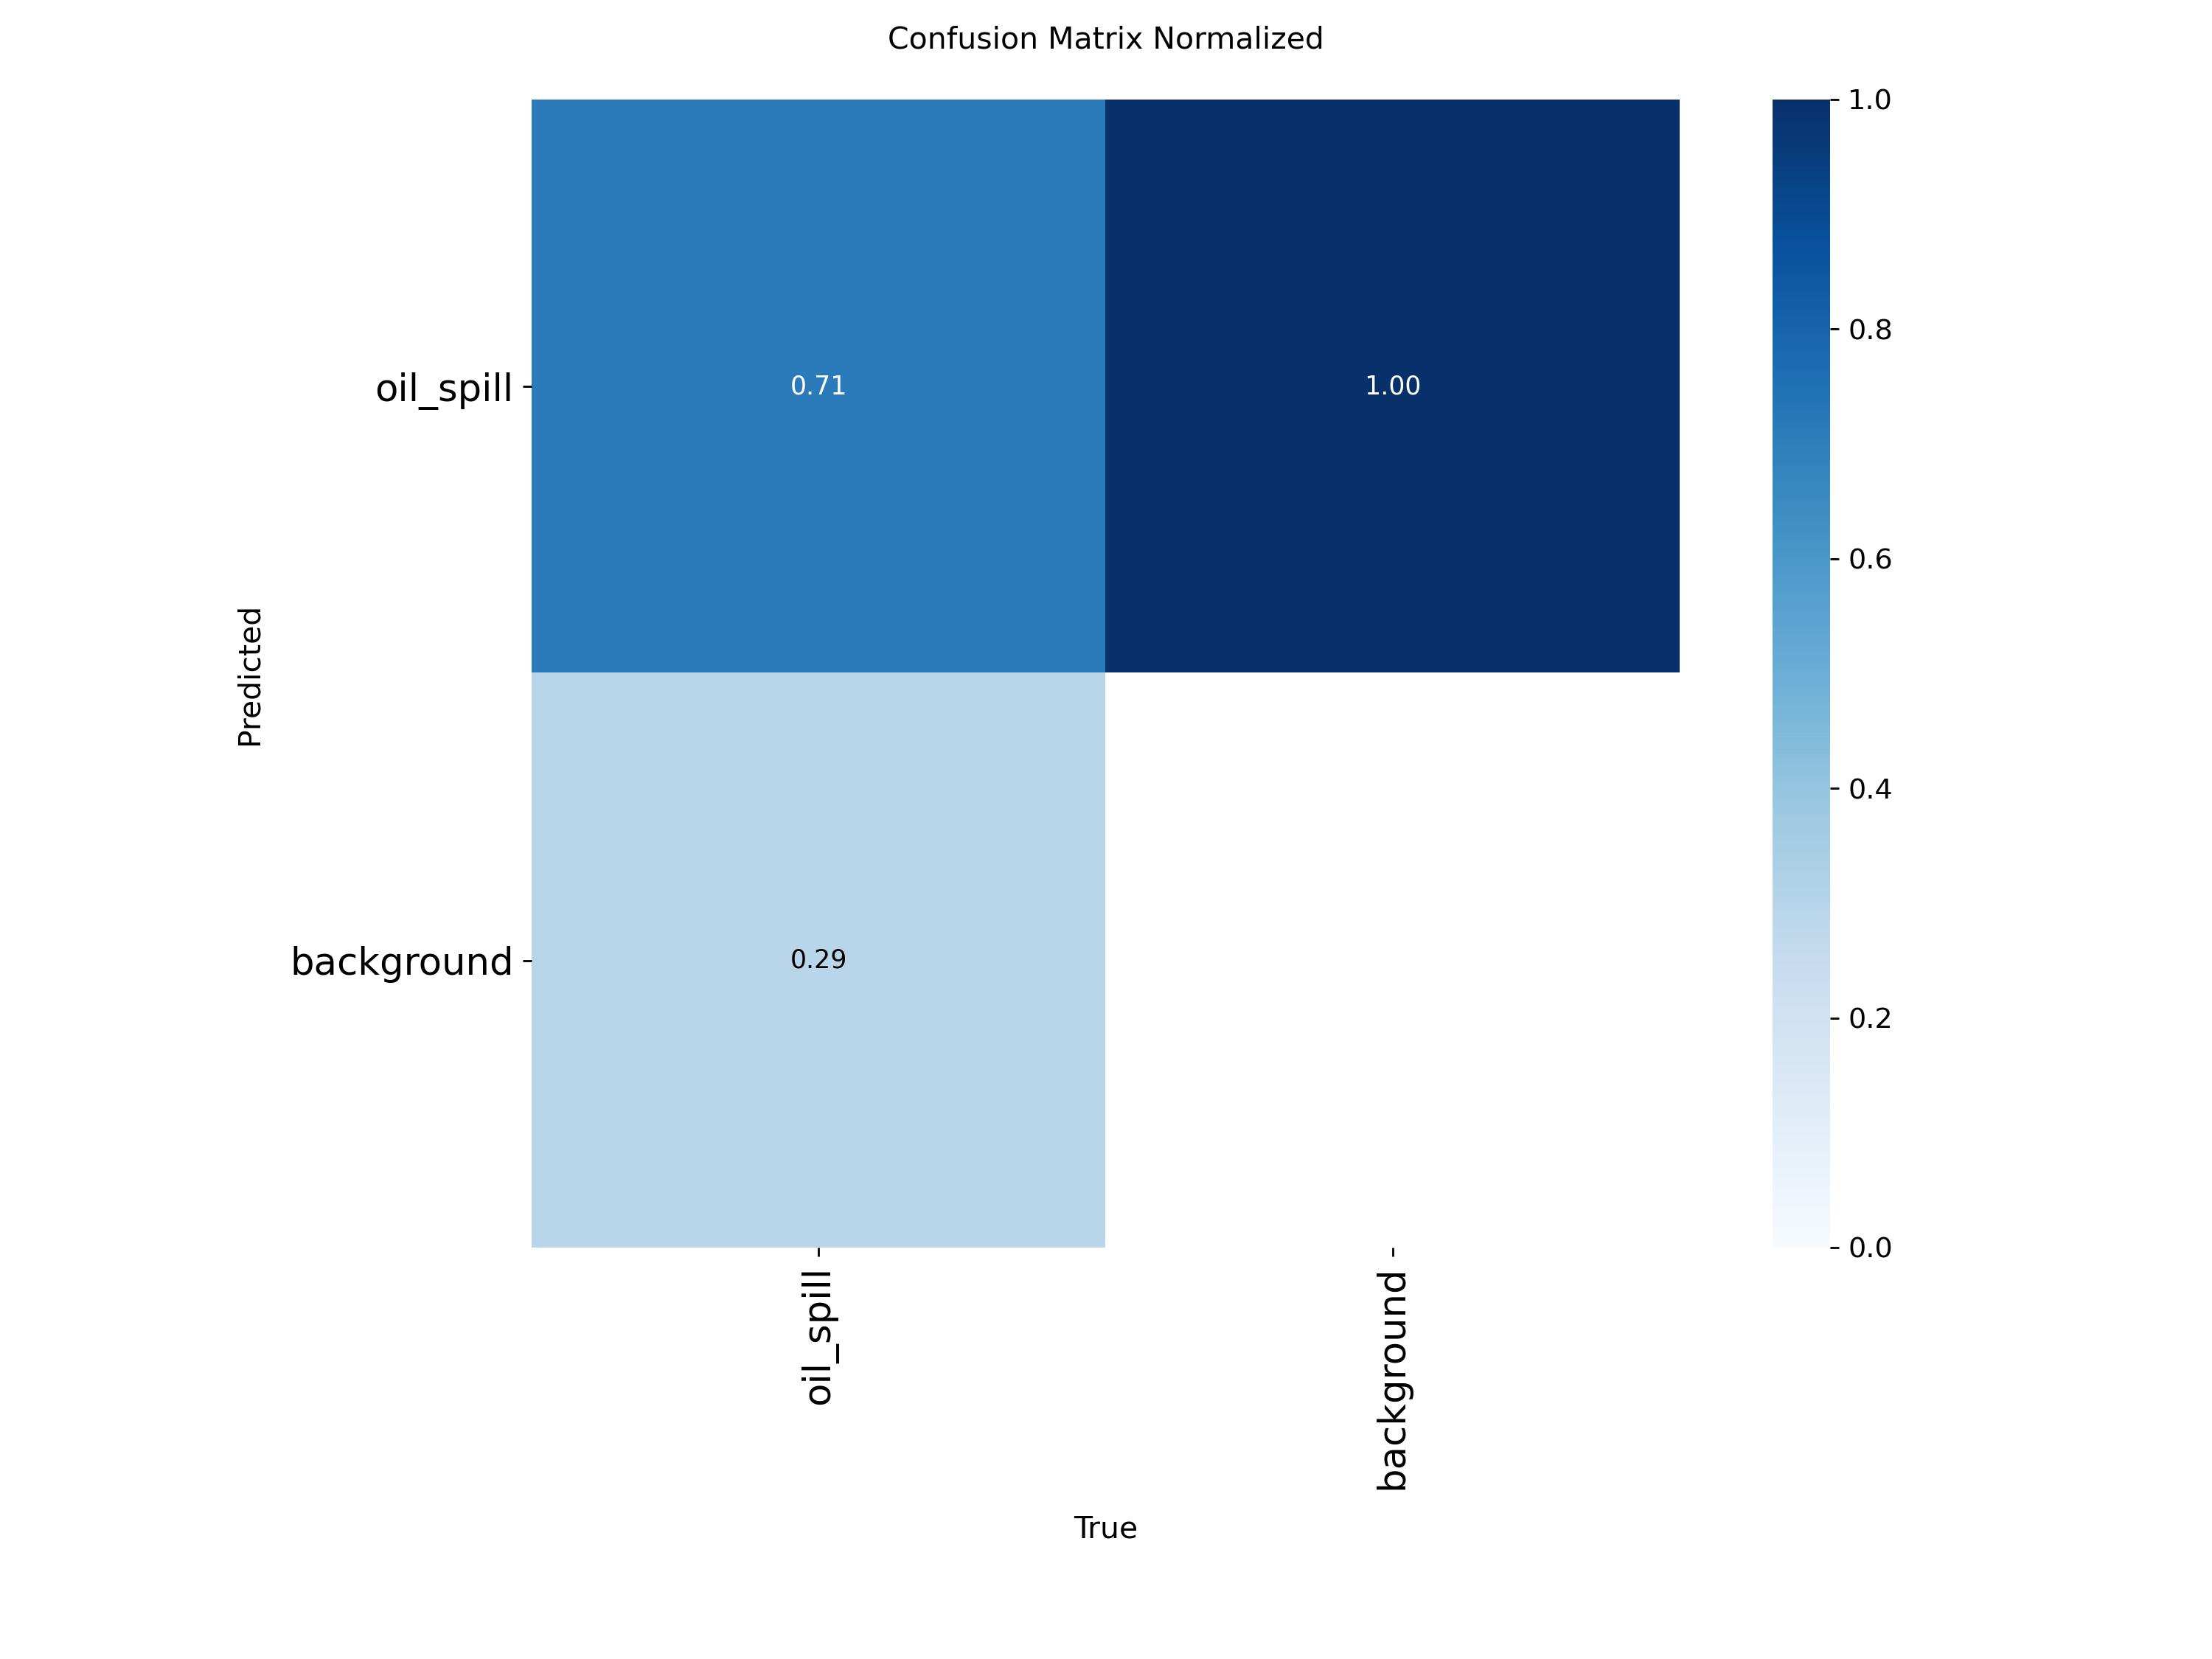

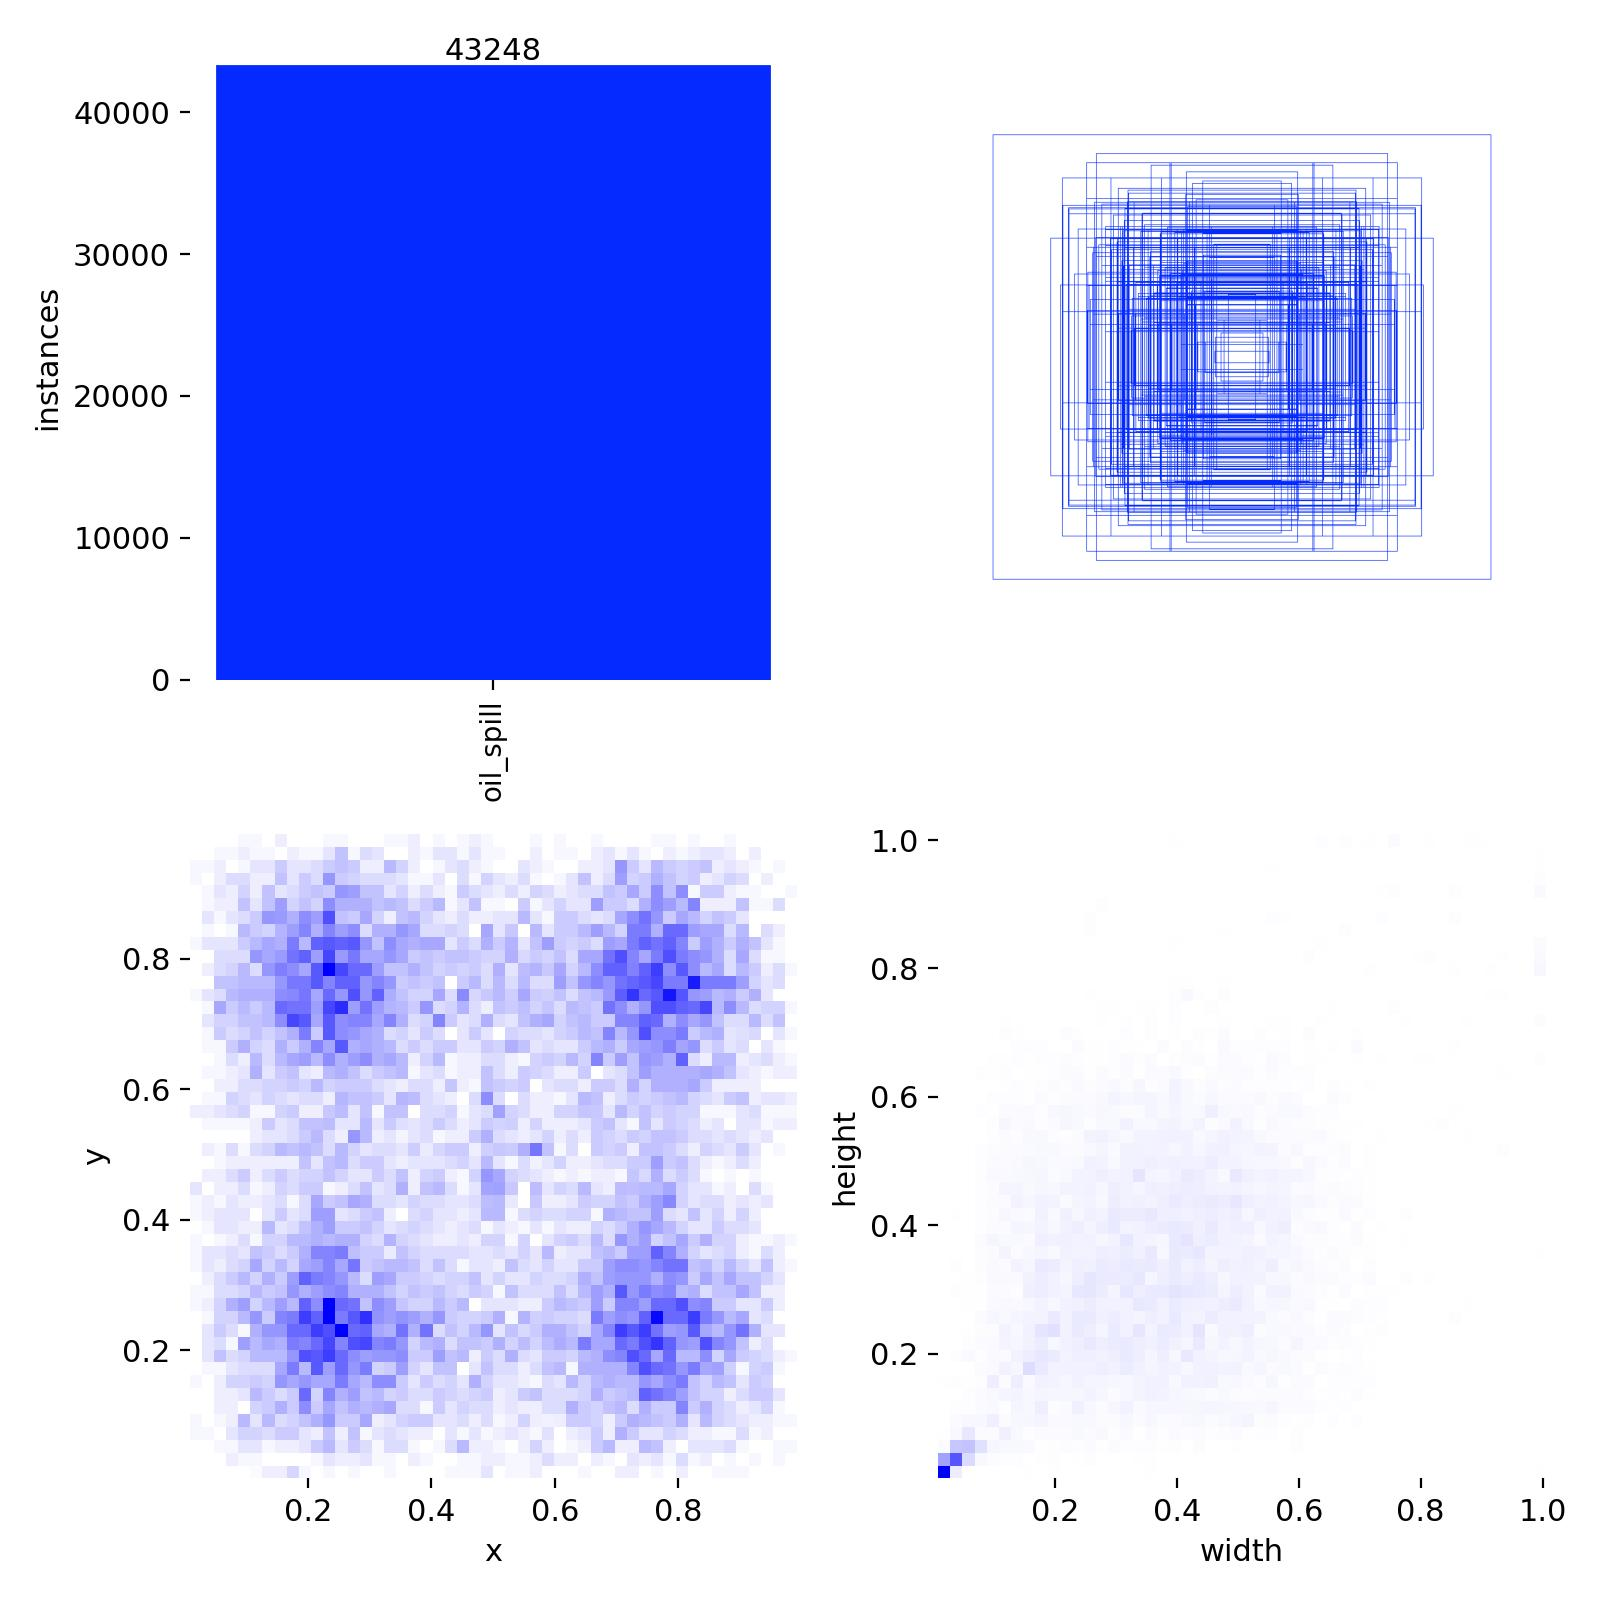

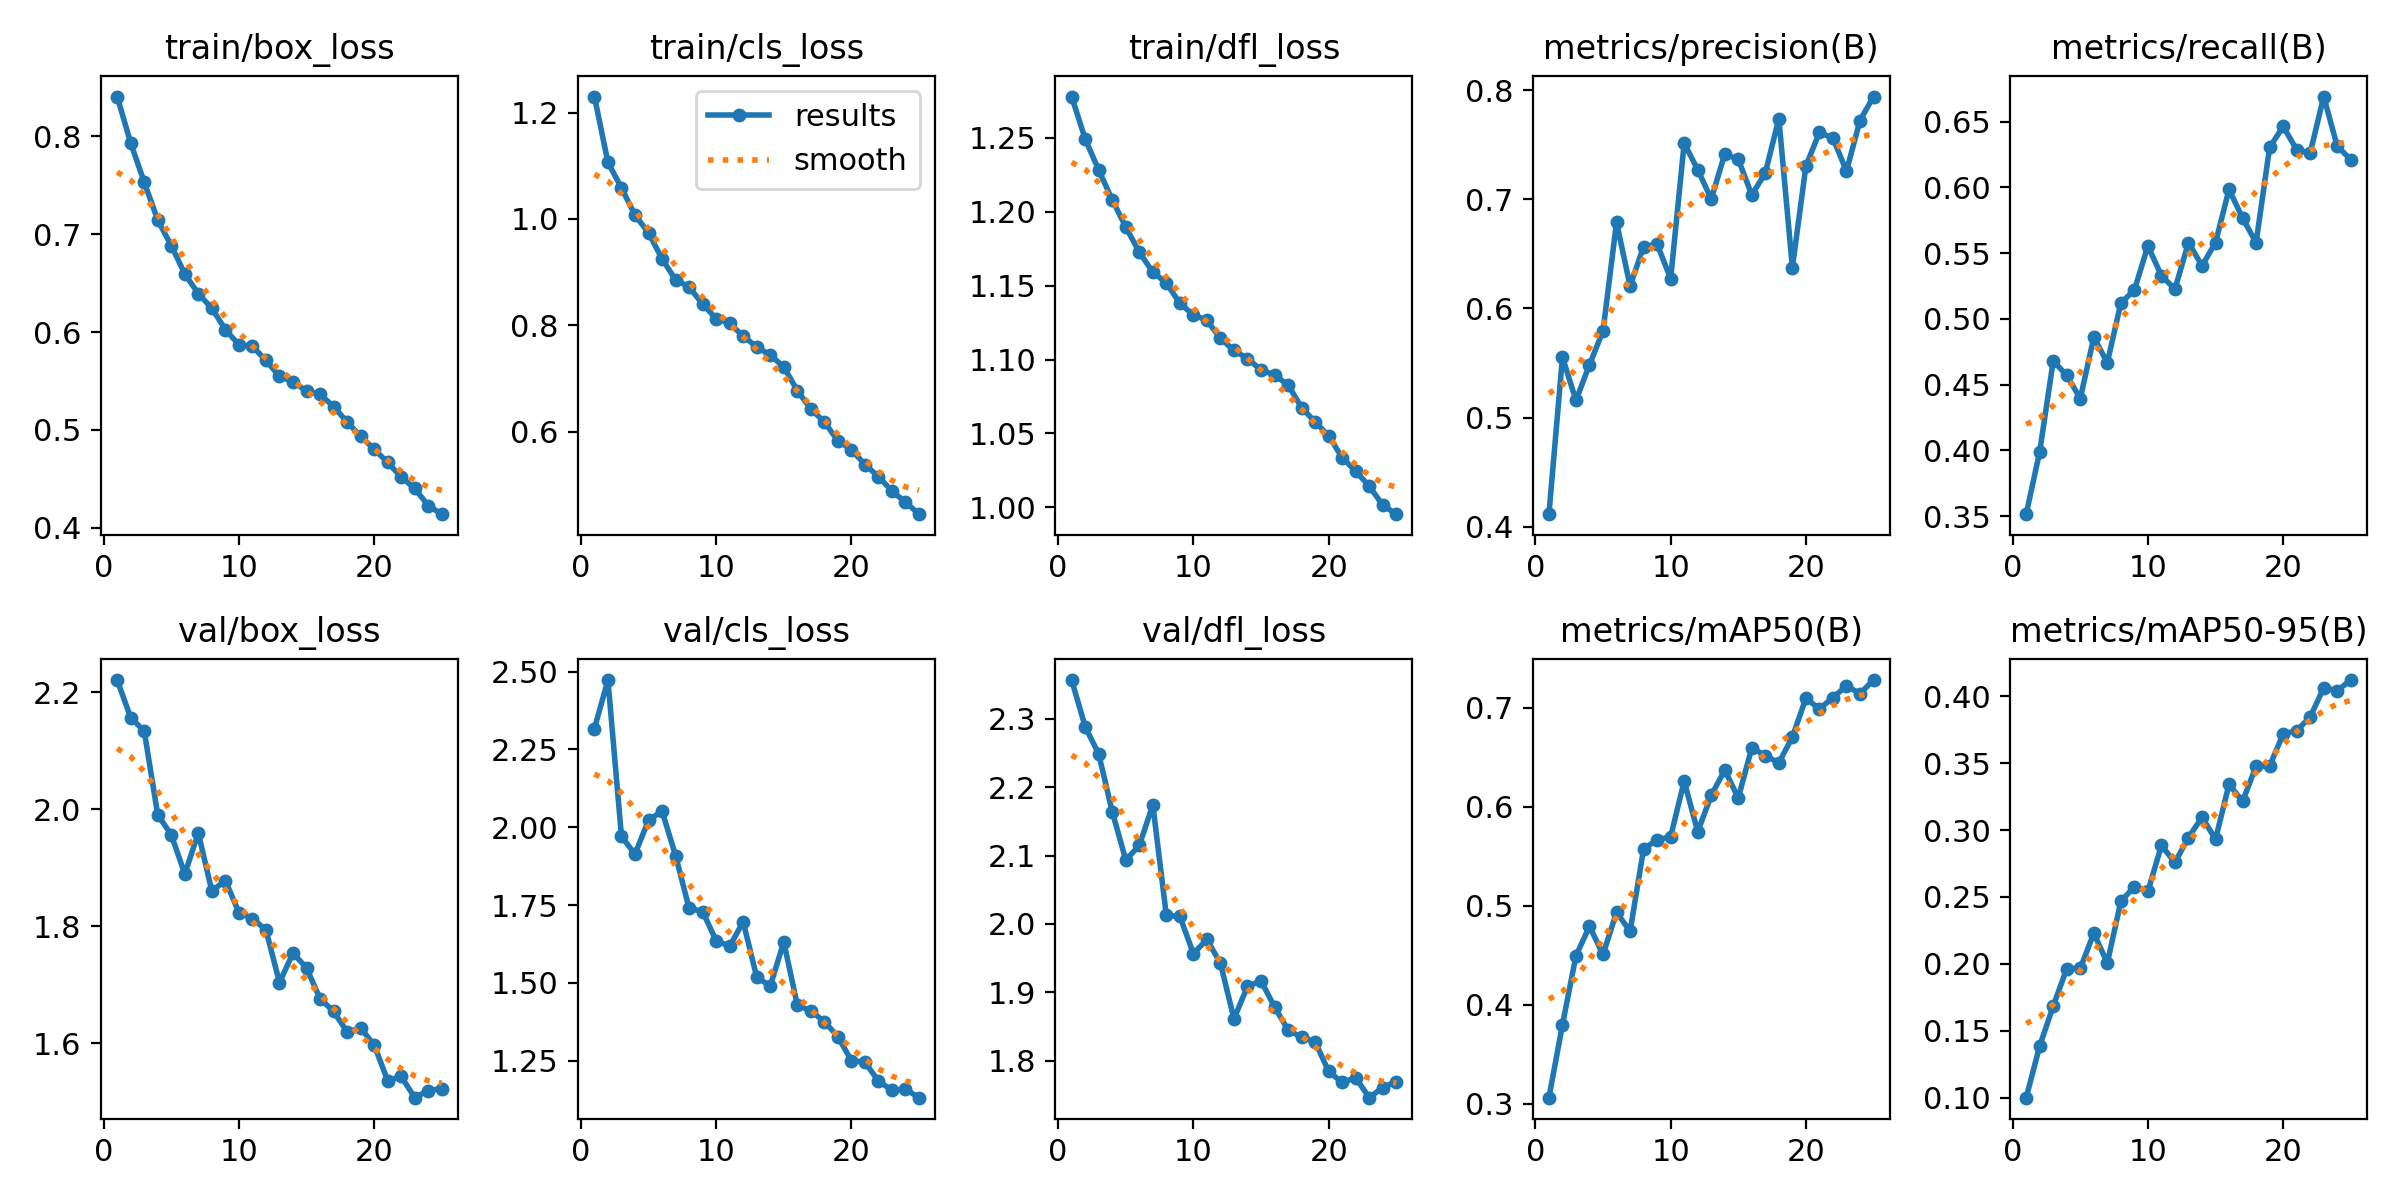

In [17]:
output_dir = Path("/kaggle/working/datasets/runs/detect/oil_spill_yolov8s2")

plot_files =   [
    "BOXP_curve.png",
    "BoxPR_curve.png",
    "BoxF1_curve.png",
    "BoxR_curve.png",
    "confusion_matrix.png",
    "confusion_matrix_normalized.png",
    "labels.jpg",
    "labels_correlogram.jpg",
    "results.png"
]


for file in plot_files:
    file_path = output_dir / file
    if file_path.exists():
        display(Image.open(file_path))


# test model

(-0.5, 1919.5, 1919.5, -0.5)

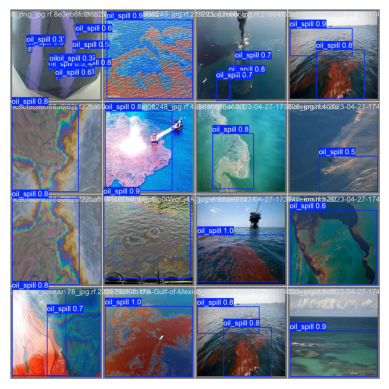

In [18]:
img = Image.open('/kaggle/working/datasets/runs/detect/oil_spill_yolov8s2/val_batch1_pred.jpg')
plt.imshow(img)
plt.axis('off')

(-0.5, 1919.5, 1919.5, -0.5)

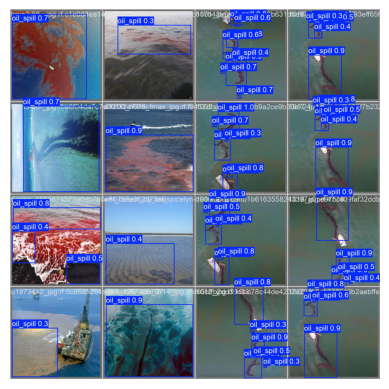

In [19]:
img = Image.open('/kaggle/working/datasets/runs/detect/oil_spill_yolov8s2/val_batch0_pred.jpg')
plt.imshow(img)
plt.axis('off')